# Execution & transaction-cost audit — final Policy C

This notebook checks the exact accounting convention of the final specification:

- **optimizer anchor:** previous target;
- **economic starting state:** previous executed holdings;
- **partial execution:** $x_t^{exec}=x_{t-1}^{exec}+\eta_t(x_t^{tar}-x_{t-1}^{exec})$;
- **cost:** 10 bp (or configured rate) on each unit actually bought or sold, i.e. on the L1/gross traded notional;
- **exposure overlay:** optional separate cost $c|k_t-k_{t-1}|$.

Run this notebook from the companion folder.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.executions.accounting import (
    partial_execute, gross_turnover, proportional_transaction_cost, exposure_turnover
)


## 1. Exact partial-execution identities

In [2]:
prev = pd.Series([0.50, 0.30, 0.20], index=list("ABC"))
target = pd.Series([0.20, 0.50, 0.30], index=list("ABC"))
rows=[]
for eta in np.linspace(0,1,11):
    ex=partial_execute(prev,target,eta)
    d0=gross_turnover(prev,target)
    rows.append({
        "eta": eta,
        "distance_to_target": gross_turnover(ex,target),
        "expected_distance": (1-eta)*d0,
        "executed_turnover": gross_turnover(prev,ex),
        "expected_turnover": eta*d0,
    })
audit=pd.DataFrame(rows)
audit["distance_error"]=audit.distance_to_target-audit.expected_distance
audit["turnover_error"]=audit.executed_turnover-audit.expected_turnover
display(audit)
print("max abs distance residual:", audit.distance_error.abs().max())
print("max abs turnover residual:", audit.turnover_error.abs().max())


,eta,distance_to_target,expected_distance,executed_turnover,expected_turnover,distance_error,turnover_error
0,0.0,0.60,0.60,0.00,0.00,0.000000e+00,0.000000e+00
1,0.1,0.54,0.54,0.06,0.06,-1.110223e-16,5.551115e-17
2,0.2,0.48,0.48,0.12,0.12,0.000000e+00,-2.775558e-17
3,0.3,0.42,0.42,0.18,0.18,-5.551115e-17,0.000000e+00
4,0.4,0.36,0.36,0.24,0.24,0.000000e+00,0.000000e+00
5,0.5,0.30,0.30,0.30,0.30,-5.551115e-17,5.551115e-17
6,0.6,0.24,0.24,0.36,0.36,-5.551115e-17,5.551115e-17
7,0.7,0.18,0.18,0.42,0.42,-2.775558e-17,0.000000e+00
8,0.8,0.12,0.12,0.48,0.48,-2.775558e-17,5.551115e-17
9,0.9,0.06,0.06,0.54,0.54,1.387779e-17,0.000000e+00


max abs distance residual: 1.1102230246251565e-16
max abs turnover residual: 5.551115123125783e-17


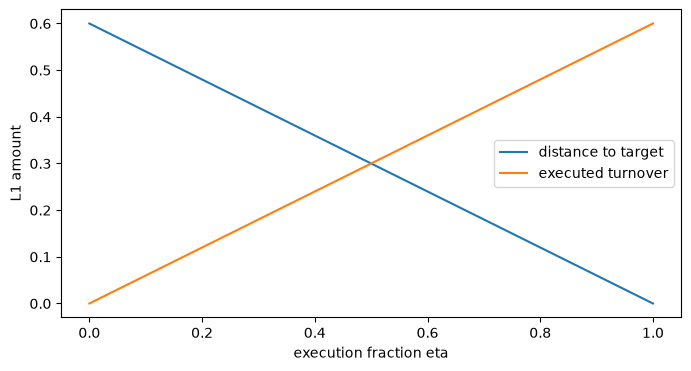

In [3]:
plt.figure(figsize=(8,4))
plt.plot(audit["eta"], audit["distance_to_target"], label="distance to target")
plt.plot(audit["eta"], audit["executed_turnover"], label="executed turnover")
plt.xlabel("execution fraction eta")
plt.ylabel("L1 amount")
plt.legend()
plt.show()


## 2. Why Policy A/B/C are not equivalent

In [4]:
previous_target = pd.Series({"A":.70,"B":.30,"C":0.0})
previous_executed = pd.Series({"A":.50,"B":.40,"C":.10})
new_target = pd.Series({"A":.20,"B":.50,"C":.30})
eta=.50

policy_A_trade_start = previous_target
policy_B_optimizer_anchor = previous_executed
policy_C_optimizer_anchor = previous_target
policy_C_trade_start = previous_executed

comparison = pd.DataFrame({
    "previous_target": previous_target,
    "previous_executed": previous_executed,
    "new_target": new_target,
    "C_executed": partial_execute(policy_C_trade_start,new_target,eta),
    "wrong_if_trade_starts_from_target": partial_execute(policy_A_trade_start,new_target,eta),
})
display(comparison)
print("Policy C actual turnover:", gross_turnover(previous_executed, comparison.C_executed))


,previous_target,previous_executed,new_target,C_executed,wrong_if_trade_starts_from_target
A,0.7,0.5,0.2,0.35,0.45
B,0.3,0.4,0.5,0.45,0.40
C,0.0,0.1,0.3,0.20,0.15


Policy C actual turnover: 0.30000000000000004


## 3. 10 bp label check: gross traded notional vs conventional one-way turnover

In [5]:
p0=pd.Series({"A":.60,"B":.40}); p1=pd.Series({"A":.40,"B":.60})
rate=.001
l1=gross_turnover(p0,p1)
one_way=.5*l1
cost=proportional_transaction_cost(p0,p1,rate)
pd.DataFrame({"value":[l1,one_way,cost,cost/one_way]}, index=["L1 gross traded notional","conventional one-way turnover","cost fraction","effective rate per one-way turnover"])


,value
L1 gross traded notional,0.4000
conventional one-way turnover,0.2000
cost fraction,0.0004
effective rate per one-way turnover,0.0020


## 4. Required exit from the feasible set

In [6]:
p0=pd.Series({"A":.50,"B":.30,"EXIT":.20})
tar=pd.Series({"A":.55,"B":.45,"EXIT":0.0})
ex=partial_execute(p0,tar,.5)
display(pd.DataFrame({"previous_executed":p0,"target":tar,"new_executed":ex}))
print("EXIT remains partially held and therefore must keep earning returns:", ex["EXIT"])
print("gross turnover including the liquidation:", gross_turnover(p0,ex))


,previous_executed,target,new_executed
A,0.5,0.55,0.525
B,0.3,0.45,0.375
EXIT,0.2,0.00,0.100


EXIT remains partially held and therefore must keep earning returns: 0.1
gross turnover including the liquidation: 0.20000000000000004


## 5. Optional exposure-overlay costs

In [7]:
dates=pd.date_range("2024-01-31", periods=6, freq="ME")
k=pd.Series([1.0,.8,.8,.55,.7,1.0], index=dates, name="k")
t=exposure_turnover(k)
out=pd.DataFrame({"k":k,"exposure_turnover":t,"cost_10bp":.001*t})
display(out)
print("cumulative pure exposure-channel cost:", out.cost_10bp.sum())


,k,exposure_turnover,cost_10bp
2024-01-31,1.00,0.00,0.00000
2024-02-29,0.80,0.20,0.00020
2024-03-31,0.80,0.00,0.00000
2024-04-30,0.55,0.25,0.00025
2024-05-31,0.70,0.15,0.00015
2024-06-30,1.00,0.30,0.00030


cumulative pure exposure-channel cost: 0.0008999999999999999


## 6. Run-level audit after a real backtest

After rerunning your final configuration, use the next cell to inspect `weights.xlsx`, `pnl.csv`, and the metadata. The exact column names depend on your saved workbook, so the cell is defensive. It is designed to **diagnose**, not silently infer missing state.

In [11]:
# Set this to your result folder, e.g. Path("results/my_final_run")
# RUN_FOLDER = None
RUN_FOLDER = ROOT / "results/advanced_smart_bayesian/"

if RUN_FOLDER is not None:
    RUN_FOLDER = Path(RUN_FOLDER)
    pnl = pd.read_csv(RUN_FOLDER / "pnl.csv")
    display(pnl.head())
    meta_path = RUN_FOLDER / "run_metadata.json"
    if meta_path.exists():
        import json
        meta=json.loads(meta_path.read_text())
        print("execution_state_policy:", meta.get("execution_state_policy"))
        print("transaction_cost_convention:", meta.get("transaction_cost_convention"))
    else:
        print("No run_metadata.json found")


,Unnamed: 0,Balance,PnL,Cost,Returns,Alpha
0,2019-01-02,1000.000000,0.000000,0.000000,0.000000,0.000000
1,2019-02-01,1077.868663,0.077869,0.000807,0.077869,0.500000
2,2019-03-01,1110.956850,0.030698,0.000441,0.030698,0.478754
3,2019-04-01,1134.812225,0.021473,0.000132,0.021473,1.000000
4,2019-05-01,1148.457350,0.012024,0.000099,0.012024,1.000000


execution_state_policy: None
transaction_cost_convention: None
